## Credit Card Default Prediction

**Name:** Mohamed Jasim Ali 

**Cohort:** DSB FT2

**Topic:** Credit Card Default Prediction

## Introduction

Credit card default is an important credit-risk problem for financial institutions. 
This project uses historical customer information, including repayment behavior, 
credit limits, bill amounts, previous payments, and demographic characteristics, 
to predict whether a customer will default on their next payment in the following month.

The dataset contains 30,000 credit card customers and 25 columns, with 
`default.payment.next.month` used as the target variable.

## Problem Statement + Aim

The aim of this project is to classify credit card customers as likely to default 
or not default on their next payment using repayment history, credit limits, 
bill amounts, previous payment amounts, and demographic information.

The model aims to support financial institutions by identifying higher-risk customers earlier 
and providing useful information for risk monitoring and collection strategies.

For model evaluation, particular attention will be given to Recall, F1-score, ROC-AUC, and PR-AUC because correctly identifying customers who may default is more 
important than relying on accuracy alone.

## Objectives

- Identify which customer characteristics are associated with credit card default.
- Explore how credit limits, bill amounts, payment amounts, and repayment history differ between defaulters and non-defaulters.
- Evaluate whether demographic characteristics provide meaningful predictive information.
- Engineer additional behavioral and financial features that may improve default prediction.
- Investigate whether relevant external Taiwan 2005 socioeconomic data adds predictive value.
- Build and compare Logistic Regression, Random Forest, XGBoost, and CatBoost classification models.
- Improve each model using class-imbalance handling, regularization, hyperparameter tuning, and other appropriate optimization techniques.
- Evaluate model performance primarily using Recall, ROC-AUC, and PR-AUC, while also monitoring Precision and F1-score.
- Identify the most suitable model for detecting customers at risk of default and translate the findings into useful credit-risk insights.

# Data Inspection

## Data Dictionary

| Column | Type | Description |
|---|---|---|
| `ID` | int | Unique customer identifier |
| `LIMIT_BAL` | int | Amount of credit granted (NTD) |
| `SEX` | int | Gender category |
| `EDUCATION` | int | Education level category |
| `MARRIAGE` | int | Marital status category |
| `AGE` | int | Customer age in years |
| `PAY_0` | int | Repayment status in September 2005 |
| `PAY_2` | int | Repayment status in August 2005 |
| `PAY_3` | int | Repayment status in July 2005 |
| `PAY_4` | int | Repayment status in June 2005 |
| `PAY_5` | int | Repayment status in May 2005 |
| `PAY_6` | int | Repayment status in April 2005 |
| `BILL_AMT1` | int | Bill statement amount in September 2005 (NTD) |
| `BILL_AMT2` | int | Bill statement amount in August 2005 (NTD) |
| `BILL_AMT3` | int | Bill statement amount in July 2005 (NTD) |
| `BILL_AMT4` | int | Bill statement amount in June 2005 (NTD) |
| `BILL_AMT5` | int | Bill statement amount in May 2005 (NTD) |
| `BILL_AMT6` | int | Bill statement amount in April 2005 (NTD) |
| `PAY_AMT1` | int | Previous payment amount in September 2005 (NTD) |
| `PAY_AMT2` | int | Previous payment amount in August 2005 (NTD) |
| `PAY_AMT3` | int | Previous payment amount in July 2005 (NTD) |
| `PAY_AMT4` | int | Previous payment amount in June 2005 (NTD) |
| `PAY_AMT5` | int | Previous payment amount in May 2005 (NTD) |
| `PAY_AMT6` | int | Previous payment amount in April 2005 (NTD) |
| `default.payment.next.month` | int | Target variable: 1 = Default, 0 = No default |

In [375]:
# organize your imports in this cell
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, average_precision_score)

## Data Overview
Load and inspect the dataset
- Source and format
- .head(), .info(), .describe(),…

In [216]:
df = pd.read_csv('./Data/UCI_Credit_Card.csv')
pd.set_option('display.max_columns', None)
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [217]:
df.shape

(30000, 25)

In [218]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   30000 non-null

In [219]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


# Data Cleaning
Handle missing values, outliers, and inconsistencies

In [220]:
df_cleaned = df.copy()

In [221]:
# Check missing values

df_cleaned.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

In [222]:
# Check duplicate rows

df_cleaned.duplicated().sum()

np.int64(0)

In [223]:
for col in ['SEX', 'EDUCATION', 'MARRIAGE']:
    print(f"\n{col}")
    print(df_cleaned[col].value_counts().sort_index())


SEX
SEX
1    11888
2    18112
Name: count, dtype: int64

EDUCATION
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


In [224]:
df_cleaned['EDUCATION'] = df_cleaned['EDUCATION'].replace({
    0: 4,
    5: 4,
    6: 4
})

df_cleaned['MARRIAGE'] = df_cleaned['MARRIAGE'].replace({
    0: 3
})

In [225]:
print("EDUCATION")
print(df_cleaned['EDUCATION'].value_counts().sort_index())

print("\nMARRIAGE")
print(df_cleaned['MARRIAGE'].value_counts().sort_index())

EDUCATION
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

MARRIAGE
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


`EDUCATION` codes 0, 5, and 6 were grouped into the `Others` category (4), while `MARRIAGE` code 0 was grouped into the `Others` category (3) to create consistent category definitions.

In [226]:
repay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

for col in repay_cols:
    print(f"\n{col}")
    print(df_cleaned[col].value_counts().sort_index())


PAY_0
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

PAY_2
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

PAY_3
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

PAY_4
PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

PAY_5
PAY_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64

PAY_6
PAY_6
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49
 5       13
 6       19
 7       46
 8        2
Name: count, dtype: int6

In [227]:
continuous_cols = [
    'LIMIT_BAL', 'AGE',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
    'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
    'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]

outlier_summary = []

for col in continuous_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = (
        (df_cleaned[col] < lower) |
        (df_cleaned[col] > upper)
    ).sum()

    outlier_summary.append({
        'Feature': col,
        'Outliers': outliers,
        'Percentage': outliers / len(df_cleaned) * 100
    })

outlier_df = pd.DataFrame(outlier_summary)

display(outlier_df.round(2))

,Feature,Outliers,Percentage
0,LIMIT_BAL,167,0.56
1,AGE,272,0.91
2,BILL_AMT1,2400,8.00
3,BILL_AMT2,2395,7.98
4,BILL_AMT3,2469,8.23
5,BILL_AMT4,2622,8.74
6,BILL_AMT5,2725,9.08
7,BILL_AMT6,2693,8.98
8,PAY_AMT1,2745,9.15
9,PAY_AMT2,2714,9.05


### Outlier Decision

Potential outliers were detected in several financial variables using the IQR method. These observations were retained because unusually high or low credit, bill, and payment amounts may represent genuine customer financial behavior and could contain useful information for predicting default.

# Exploratory Data Analysis (EDA)
Answer objectives using visual and statistical insights
- Trends, relationships, anomalies
- Outlier and missing values treatment
- Univariate, bivariate, or multivariate analysis
    - Histograms, box plots, bar charts
    - Correlation matrix for continuous columns (required if applicable)


In [229]:
# Target class distribution

target = 'default.payment.next.month'

target_summary = pd.DataFrame({
    'Count': df_cleaned[target].value_counts().sort_index(),
    'Percentage': df_cleaned[target].value_counts(normalize=True).sort_index() * 100
})

display(target_summary.round(2))

,Count,Percentage
default.payment.next.month,,
0,23364,77.88
1,6636,22.12


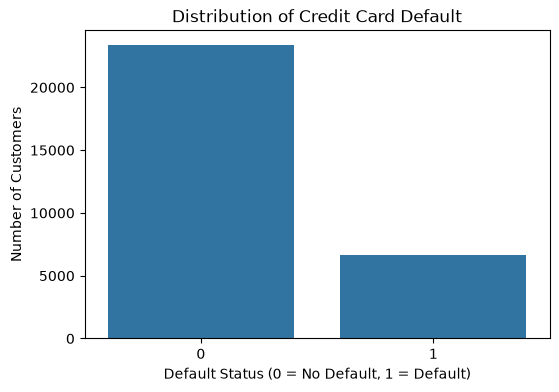

In [230]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_cleaned,
    x=target
)

plt.title('Distribution of Credit Card Default')
plt.xlabel('Default Status (0 = No Default, 1 = Default)')
plt.ylabel('Number of Customers')
plt.show()

The target is moderately imbalanced: 77.88% of customers did not default, while 22.12% defaulted. Therefore, accuracy alone may be misleading and the class imbalance should be considered during modeling.

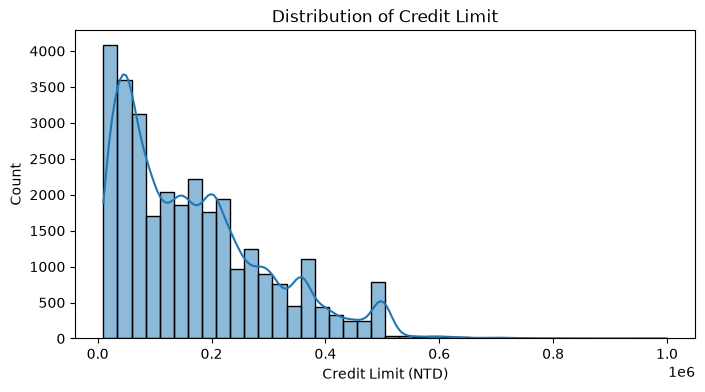

In [231]:
plt.figure(figsize=(8, 4))

sns.histplot(
    data=df_cleaned,
    x='LIMIT_BAL',
    bins=40,
    kde=True
)

plt.title('Distribution of Credit Limit')
plt.xlabel('Credit Limit (NTD)')
plt.show()

In [232]:
limit_by_default = (
    df_cleaned
    .groupby(target)['LIMIT_BAL']
    .agg(['mean', 'median'])
)

display(limit_by_default.round(2))

,mean,median
default.payment.next.month,,
0,178099.73,150000.0
1,130109.66,90000.0


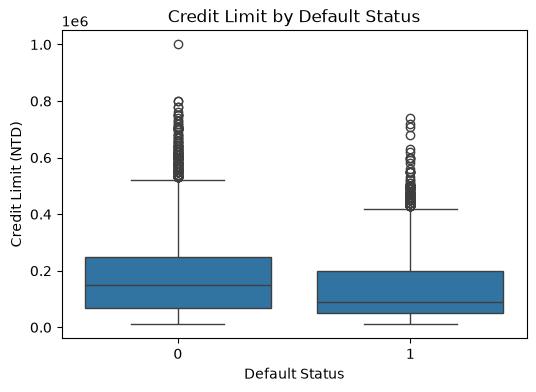

In [233]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df_cleaned,
    x=target,
    y='LIMIT_BAL'
)

plt.title('Credit Limit by Default Status')
plt.xlabel('Default Status')
plt.ylabel('Credit Limit (NTD)')
plt.show()

Customers who defaulted generally had lower credit limits than non-defaulters, suggesting that credit limit contains useful information for default-risk prediction.

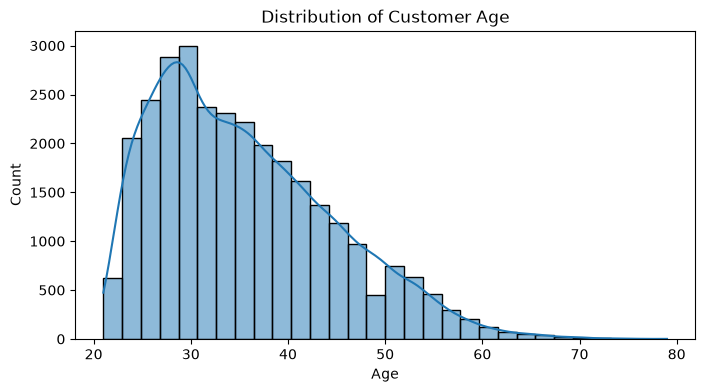

In [234]:
plt.figure(figsize=(8, 4))

sns.histplot(
    data=df_cleaned,
    x='AGE',
    bins=30,
    kde=True
)

plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.show()

In [235]:
age_default = (
    df_cleaned
    .groupby(target)['AGE']
    .agg(['mean', 'median'])
)

display(age_default.round(2))

,mean,median
default.payment.next.month,,
0,35.42,34.0
1,35.73,34.0


In [236]:
sex_default = (
    df_cleaned
    .groupby('SEX')[target]
    .mean()
    .mul(100)
)

display(sex_default.round(2))

SEX
1    24.17
2    20.78
Name: default.payment.next.month, dtype: float64

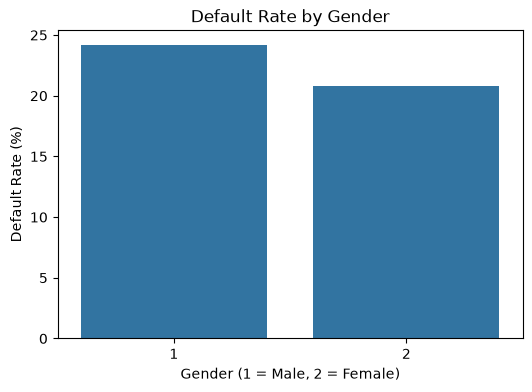

In [237]:
plt.figure(figsize=(6, 4))

sns.barplot(
    x=sex_default.index,
    y=sex_default.values
)

plt.title('Default Rate by Gender')
plt.xlabel('Gender (1 = Male, 2 = Female)')
plt.ylabel('Default Rate (%)')
plt.show()

In [238]:
education_default = (
    df_cleaned
    .groupby('EDUCATION')[target]
    .mean()
    .mul(100)
)

display(education_default.round(2))

EDUCATION
1    19.23
2    23.73
3    25.16
4     7.05
Name: default.payment.next.month, dtype: float64

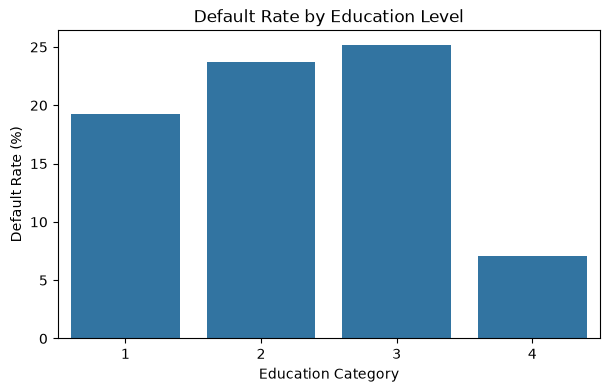

In [239]:
plt.figure(figsize=(7, 4))

sns.barplot(
    x=education_default.index,
    y=education_default.values
)

plt.title('Default Rate by Education Level')
plt.xlabel('Education Category')
plt.ylabel('Default Rate (%)')
plt.show()

In [240]:
marriage_default = (
    df_cleaned
    .groupby('MARRIAGE')[target]
    .mean()
    .mul(100)
)

display(marriage_default.round(2))

MARRIAGE
1    23.47
2    20.93
3    23.61
Name: default.payment.next.month, dtype: float64

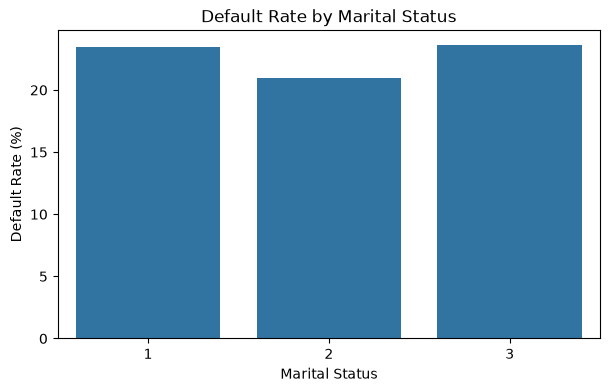

In [241]:
plt.figure(figsize=(7, 4))

sns.barplot(
    x=marriage_default.index,
    y=marriage_default.values
)

plt.title('Default Rate by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Default Rate (%)')
plt.show()

In [242]:
pay0_default = (
    df_cleaned
    .groupby('PAY_0')[target]
    .agg(['count', 'mean'])
)

pay0_default['Default Rate (%)'] = pay0_default['mean'] * 100

display(
    pay0_default[['count', 'Default Rate (%)']]
    .round(2)
)

,count,Default Rate (%)
PAY_0,,
-2,2759,13.23
-1,5686,16.78
0,14737,12.81
1,3688,33.95
2,2667,69.14
3,322,75.78
4,76,68.42
5,26,50.00
6,11,54.55


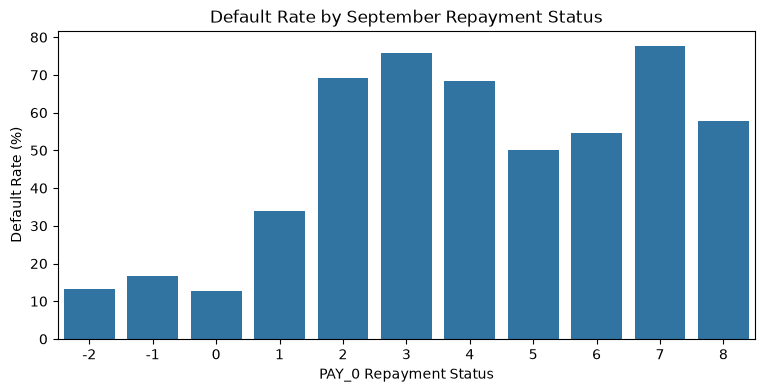

In [243]:
plt.figure(figsize=(9, 4))

sns.barplot(
    x=pay0_default.index,
    y=pay0_default['Default Rate (%)']
)

plt.title('Default Rate by September Repayment Status')
plt.xlabel('PAY_0 Repayment Status')
plt.ylabel('Default Rate (%)')
plt.show()

Default risk increases substantially as repayment delay increases. Repayment history therefore appears to be one of the strongest groups of predictors in the dataset.

In [244]:
repayment_by_default = (
    df_cleaned
    .groupby(target)[repay_cols]
    .mean()
    .T
)

repayment_by_default.columns = ['No Default', 'Default']

display(repayment_by_default.round(3))

,No Default,Default
PAY_0,-0.211,0.668
PAY_2,-0.302,0.458
PAY_3,-0.316,0.362
PAY_4,-0.356,0.255
PAY_5,-0.389,0.168
PAY_6,-0.406,0.112


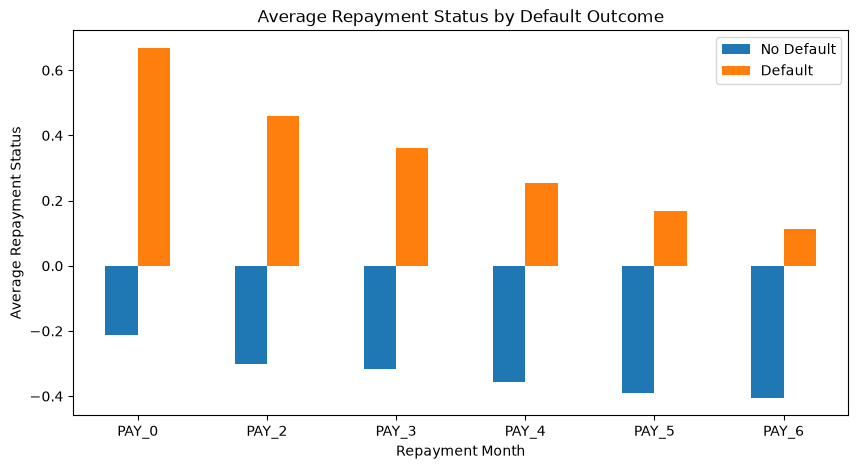

In [245]:
repayment_by_default.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Average Repayment Status by Default Outcome')
plt.xlabel('Repayment Month')
plt.ylabel('Average Repayment Status')
plt.xticks(rotation=0)
plt.show()

In [246]:
bill_cols = [
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
    'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6'
]

payment_cols = [
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
    'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]

In [249]:
bill_by_default = (
    df_cleaned
    .groupby(target)[bill_cols]
    .mean()
    .T
)

bill_by_default.columns = ['No Default', 'Default']

display(bill_by_default.round(2))

,No Default,Default
BILL_AMT1,51994.23,48509.16
BILL_AMT2,49717.44,47283.62
BILL_AMT3,47533.37,45181.60
BILL_AMT4,43611.17,42036.95
BILL_AMT5,40530.45,39540.19
BILL_AMT6,39042.27,38271.44


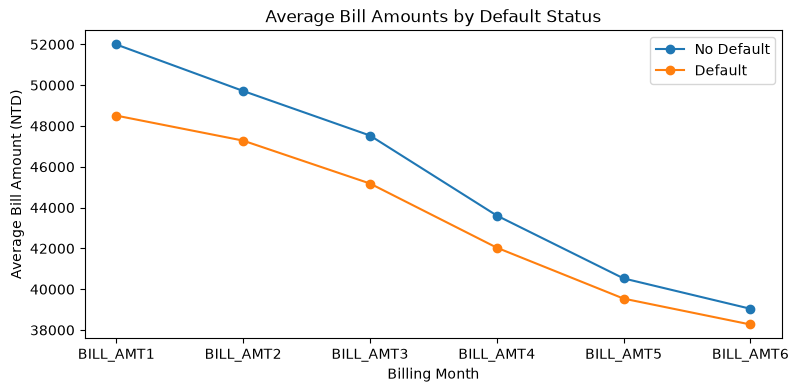

In [250]:
bill_by_default.plot(
    kind='line',
    marker='o',
    figsize=(9, 4)
)

plt.title('Average Bill Amounts by Default Status')
plt.xlabel('Billing Month')
plt.ylabel('Average Bill Amount (NTD)')
plt.xticks(range(len(bill_cols)), bill_cols)
plt.show()

In [251]:
payment_by_default = (
    df_cleaned
    .groupby(target)[payment_cols]
    .mean()
    .T
)

payment_by_default.columns = ['No Default', 'Default']

display(payment_by_default.round(2))

,No Default,Default
PAY_AMT1,6307.34,3397.04
PAY_AMT2,6640.47,3388.65
PAY_AMT3,5753.50,3367.35
PAY_AMT4,5300.53,3155.63
PAY_AMT5,5248.22,3219.14
PAY_AMT6,5719.37,3441.48


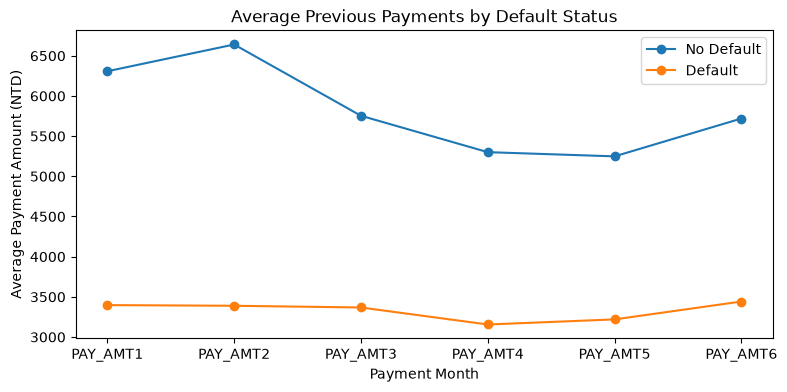

In [252]:
payment_by_default.plot(
    kind='line',
    marker='o',
    figsize=(9, 4)
)

plt.title('Average Previous Payments by Default Status')
plt.xlabel('Payment Month')
plt.ylabel('Average Payment Amount (NTD)')
plt.xticks(range(len(payment_cols)), payment_cols)
plt.show()

Non-defaulters generally made larger previous payments, while bill amounts alone showed weaker separation between the two groups. This suggests that payment behavior may provide more useful risk information than bill size alone.

In [253]:
correlation_features = continuous_cols + repay_cols + [target]

target_correlations = (
    df_cleaned[correlation_features]
    .corr()[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
)

display(target_correlations.round(4))

PAY_0        0.3248
PAY_2        0.2636
PAY_3        0.2353
PAY_4        0.2166
PAY_5        0.2041
PAY_6        0.1869
LIMIT_BAL   -0.1535
PAY_AMT1    -0.0729
PAY_AMT2    -0.0586
PAY_AMT4    -0.0568
PAY_AMT3    -0.0563
PAY_AMT5    -0.0551
PAY_AMT6    -0.0532
BILL_AMT1   -0.0196
BILL_AMT2   -0.0142
BILL_AMT3   -0.0141
AGE          0.0139
BILL_AMT4   -0.0102
BILL_AMT5   -0.0068
BILL_AMT6   -0.0054
Name: default.payment.next.month, dtype: float64

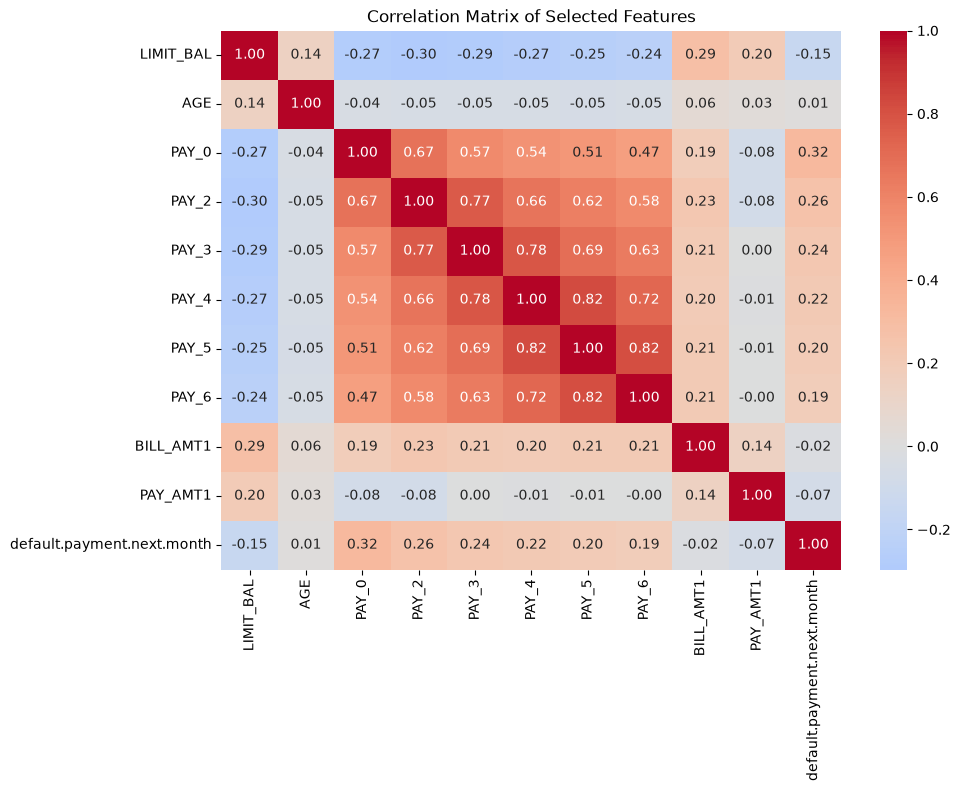

In [254]:
heatmap_cols = [
    'LIMIT_BAL',
    'AGE',
    'PAY_0',
    'PAY_2',
    'PAY_3',
    'PAY_4',
    'PAY_5',
    'PAY_6',
    'BILL_AMT1',
    'PAY_AMT1',
    target
]

plt.figure(figsize=(10, 7))

sns.heatmap(
    df_cleaned[heatmap_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Selected Features')
plt.show()

In [255]:
categorical_test_cols = [
    'SEX',
    'EDUCATION',
    'MARRIAGE',
    'PAY_0',
    'PAY_2',
    'PAY_3',
    'PAY_4',
    'PAY_5',
    'PAY_6'
]

chi_square_results = []

for col in categorical_test_cols:

    contingency_table = pd.crosstab(
        df_cleaned[col],
        df_cleaned[target]
    )

    chi2, p, dof, expected = chi2_contingency(contingency_table)

    chi_square_results.append({
        'Feature': col,
        'Chi-Square': chi2,
        'p-value': p
    })

chi_square_df = pd.DataFrame(chi_square_results)

display(
    chi_square_df
    .sort_values('Chi-Square', ascending=False)
    .round(4)
)

,Feature,Chi-Square,p-value
3,PAY_0,5365.9650,0.0
4,PAY_2,3474.4668,0.0
5,PAY_3,2622.4621,0.0
6,PAY_4,2341.4699,0.0
7,PAY_5,2197.6949,0.0
8,PAY_6,1886.8353,0.0
1,EDUCATION,160.4100,0.0
0,SEX,47.7088,0.0
2,MARRIAGE,28.1303,0.0


The categorical variables show statistically significant associations with default. However, repayment-status variables have substantially larger Chi-square statistics than the demographic variables, indicating much stronger relationships with default behavior.

Statistical significance alone does not determine final model importance, so these results are considered alongside model-based feature importance and predictive performance.

### Insights

- The target is moderately imbalanced, with approximately 22% of customers defaulting.
- Repayment history shows the strongest relationship with future default.
- Customers who default generally have lower credit limits.
- Previous payment amounts show clearer differences between defaulters and non-defaulters than bill amounts alone.
- Demographic variables show some association with default, but their relationships are weaker than repayment behavior.
- Financial variables contain substantial variation and outliers, which were retained because they may represent genuine customer behavior.

### EDA for Modeling

The EDA indicates that repayment behavior provides the strongest predictive signal, while financial and demographic variables provide additional supporting information.

The target is moderately imbalanced, so class imbalance will be addressed during modeling and performance will be evaluated using Recall, ROC-AUC, PR-AUC, Precision, and F1-score rather than accuracy alone.

The repeated monthly repayment, billing, and payment variables also support creating summary features that capture customer behavior across several months.

### Feature Selection

No features were dropped a priori based on the correlation matrix or chi-square results. 
All raw and engineered features were retained going into modeling, and feature importance 
from the tree-based models (Random Forest, XGBoost, CatBoost) and the Logistic Regression 
coefficients were used post-hoc to assess which features actually drive predictions. This 
avoids discarding features that might matter in combination even if their individual 
correlation with the target is weak.

# Data Preprocessing & Feature Engineering
Transforming, encoding, standardization and preparing features

In [258]:
df_model = df_cleaned.copy()
df_model = df_model.drop(columns=['ID'])

In [259]:
repay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

bill_cols = [
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
    'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6'
]

payment_cols = [
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
    'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]

df_model['DELAY_COUNT'] = (df_model[repay_cols] > 0).sum(axis=1)

df_model['MAX_DELAY'] = df_model[repay_cols].max(axis=1)

df_model['AVG_BILL_AMT'] = df_model[bill_cols].mean(axis=1)

df_model['AVG_PAY_AMT'] = df_model[payment_cols].mean(axis=1)

df_model['UTILIZATION_RATIO'] = (
    df_model['AVG_BILL_AMT'] / df_model['LIMIT_BAL']
)

df_model[
    ['DELAY_COUNT', 'MAX_DELAY', 'AVG_BILL_AMT',
     'AVG_PAY_AMT', 'UTILIZATION_RATIO']
].head()

,DELAY_COUNT,MAX_DELAY,AVG_BILL_AMT,AVG_PAY_AMT,UTILIZATION_RATIO
0,2,2,1284.000000,114.833333,0.064200
1,2,2,2846.166667,833.333333,0.023718
2,0,0,16942.166667,1836.333333,0.188246
3,0,0,38555.666667,1398.000000,0.771113
4,0,0,18223.166667,9841.500000,0.364463


In [261]:
# Separate predictors and target
X = df_model.drop(columns=['default.payment.next.month'])
y = df_model['default.payment.next.month']
# 80% training data and 20% test data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (24000, 28)
X_test: (6000, 28)
y_train: (24000,)
y_test: (6000,)


In [263]:
# Define feature groups

categorical_features = [
    'SEX',
    'EDUCATION',
    'MARRIAGE'
]

numerical_features = [
    col for col in X_train.columns
    if col not in categorical_features
]

print("Categorical features:", categorical_features)
print("Number of numerical features:", len(numerical_features))

Categorical features: ['SEX', 'EDUCATION', 'MARRIAGE']
Number of numerical features: 25


In [264]:
# Preprocessor for Logistic Regression
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

# Preprocessor for tree-based models
tree_preprocessor = ColumnTransformer([
    ('num', 'passthrough', numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

print("Preprocessors ready")

Preprocessors ready


### External Data Enrichment Experiment

Relevant Taiwan 2005 socioeconomic data was investigated to determine whether additional income and labor-participation information could improve default prediction. These variables are group-level proxies rather than actual customer-level income or employment data.

In [265]:
# Create Taiwan 2005 income proxy features

X_train_external = X_train.copy()

def get_age_group(age):
    if age <= 24:
        return '20-24'
    elif age <= 29:
        return '25-29'
    elif age <= 34:
        return '30-34'
    elif age <= 39:
        return '35-39'
    elif age <= 44:
        return '40-44'
    elif age <= 49:
        return '45-49'
    elif age <= 54:
        return '50-54'
    elif age <= 59:
        return '55-59'
    elif age <= 64:
        return '60-64'
    else:
        return '65+'


income_lookup = {
    '20-24': {1:24242, 2:24242, 3:23118, 4:23756},
    '25-29': {1:34660, 2:34660, 3:26491, 4:29608},
    '30-34': {1:44866, 2:44866, 3:29392, 4:34562},
    '35-39': {1:52864, 2:52864, 3:31946, 4:36624},
    '40-44': {1:59201, 2:59201, 3:32752, 4:38399},
    '45-49': {1:62935, 2:62935, 3:35961, 4:39002},
    '50-54': {1:61942, 2:61942, 3:37785, 4:38547},
    '55-59': {1:69484, 2:69484, 3:50605, 4:42534},
    '60-64': {1:69096, 2:69096, 3:42871, 4:36720},
    '65+':   {1:56133, 2:56133, 3:30224, 4:29688}
}

X_train_external['EXPECTED_MONTHLY_INCOME'] = X_train_external.apply(
    lambda row: income_lookup[get_age_group(row['AGE'])][row['EDUCATION']],
    axis=1
)

X_train_external['CREDIT_INCOME_RATIO'] = (
    X_train_external['LIMIT_BAL'] /
    X_train_external['EXPECTED_MONTHLY_INCOME']
)

X_train_external['BILL_INCOME_RATIO'] = (
    X_train_external['AVG_BILL_AMT'] /
    X_train_external['EXPECTED_MONTHLY_INCOME']
)

X_train_external['PAYMENT_INCOME_RATIO'] = (
    X_train_external['AVG_PAY_AMT'] /
    X_train_external['EXPECTED_MONTHLY_INCOME']
)

X_train_external[
    [
        'EXPECTED_MONTHLY_INCOME',
        'CREDIT_INCOME_RATIO',
        'BILL_INCOME_RATIO',
        'PAYMENT_INCOME_RATIO'
    ]
].head()

,EXPECTED_MONTHLY_INCOME,CREDIT_INCOME_RATIO,BILL_INCOME_RATIO,PAYMENT_INCOME_RATIO
22788,44866,3.566175,3.688539,0.146733
29006,44866,3.343289,0.000197,0.000197
16950,61942,0.161441,0.138466,0.010806
22280,34660,6.347374,5.373985,0.200457
11346,44866,6.909464,0.000676,0.005669


In [266]:
# Add Taiwan 2005 labor participation proxy features

def age_labor_participation(age):
    if age <= 24:
        return 31.96
    elif age <= 44:
        return 81.69
    elif age <= 64:
        return 60.64
    else:
        return 7.51


education_labor_lookup = {
    1: 67.08,
    2: 67.08,
    3: 63.37,
    4: 57.72
}


X_train_external['AGE_LABOR_PARTICIPATION'] = (
    X_train_external['AGE'].apply(age_labor_participation)
)

X_train_external['EDUCATION_LABOR_PARTICIPATION'] = (
    X_train_external['EDUCATION'].map(education_labor_lookup)
)


X_train_external[
    [
        'EXPECTED_MONTHLY_INCOME',
        'CREDIT_INCOME_RATIO',
        'BILL_INCOME_RATIO',
        'PAYMENT_INCOME_RATIO',
        'AGE_LABOR_PARTICIPATION',
        'EDUCATION_LABOR_PARTICIPATION'
    ]
].head()

,EXPECTED_MONTHLY_INCOME,CREDIT_INCOME_RATIO,BILL_INCOME_RATIO,PAYMENT_INCOME_RATIO,AGE_LABOR_PARTICIPATION,EDUCATION_LABOR_PARTICIPATION
22788,44866,3.566175,3.688539,0.146733,81.69,67.08
29006,44866,3.343289,0.000197,0.000197,81.69,67.08
16950,61942,0.161441,0.138466,0.010806,60.64,67.08
22280,34660,6.347374,5.373985,0.200457,81.69,67.08
11346,44866,6.909464,0.000676,0.005669,81.69,67.08


In [279]:
# Compare Original Features vs External Taiwan Data

# Weight the default class because it is smaller
class_weight_ratio = (
    (y_train == 0).sum() /
    (y_train == 1).sum()
)

# Create the same XGBoost model for both datasets
def create_xgb_model(X_data):

    categorical = ['SEX', 'EDUCATION', 'MARRIAGE']
    numerical = [col for col in X_data.columns if col not in categorical]

    preprocessor_external = ColumnTransformer([
        ('num', 'passthrough', numerical),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
    ])

    return Pipeline([
        ('preprocessor', preprocessor_external),

        ('classifier', XGBClassifier(
            n_estimators=100,
            max_depth=3,
            learning_rate=0.1,
            scale_pos_weight=class_weight_ratio,
            random_state=42,
            eval_metric='logloss',
            tree_method='hist',
            n_jobs=1
        ))
    ])


# Create models
xgb_original = create_xgb_model(X_train)
xgb_external = create_xgb_model(X_train_external)


# Evaluate Original Features
original_scores = cross_validate(
    xgb_original,
    X_train,
    y_train,
    cv=10,
    scoring=[
        'accuracy',
        'precision',
        'recall',
        'f1',
        'roc_auc',
        'average_precision'
    ],
    n_jobs=-1
)


# Evaluate External Features
external_scores = cross_validate(
    xgb_external,
    X_train_external,
    y_train,
    cv=10,
    scoring=[
        'accuracy',
        'precision',
        'recall',
        'f1',
        'roc_auc',
        'average_precision'
    ],
    n_jobs=-1
)


# Comparison table
external_comparison = pd.DataFrame({
    'Features': [
        'Original Features',
        'Income + Labor External Data'
    ],

    'Accuracy': [
        original_scores['test_accuracy'].mean(),
        external_scores['test_accuracy'].mean()
    ],

    'Precision': [
        original_scores['test_precision'].mean(),
        external_scores['test_precision'].mean()
    ],

    'Recall': [
        original_scores['test_recall'].mean(),
        external_scores['test_recall'].mean()
    ],

    'F1': [
        original_scores['test_f1'].mean(),
        external_scores['test_f1'].mean()
    ],

    'ROC-AUC': [
        original_scores['test_roc_auc'].mean(),
        external_scores['test_roc_auc'].mean()
    ],

    'PR-AUC': [
        original_scores['test_average_precision'].mean(),
        external_scores['test_average_precision'].mean()
    ]
})

print("Class Weight Ratio:", round(class_weight_ratio, 2))

display(external_comparison.round(4))

Class Weight Ratio: 3.52


,Features,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Original Features,0.7545,0.4612,0.6483,0.5389,0.7863,0.5626
1,Income + Labor External Data,0.7544,0.4610,0.6500,0.5393,0.7860,0.5620


In [280]:
# Add external socioeconomic features

def add_external_features(X_data):

    X_new = X_data.copy()

    age_group = X_new['AGE'].apply(get_age_group)

    X_new['EXPECTED_MONTHLY_INCOME'] = [
        income_lookup[group][education]
        for group, education in zip(age_group, X_new['EDUCATION'])
    ]

    X_new['CREDIT_INCOME_RATIO'] = (
        X_new['LIMIT_BAL'] / X_new['EXPECTED_MONTHLY_INCOME']
    )

    X_new['BILL_INCOME_RATIO'] = (
        X_new['AVG_BILL_AMT'] / X_new['EXPECTED_MONTHLY_INCOME']
    )

    X_new['PAYMENT_INCOME_RATIO'] = (
        X_new['AVG_PAY_AMT'] / X_new['EXPECTED_MONTHLY_INCOME']
    )

    X_new['AGE_LABOR_PARTICIPATION'] = X_new['AGE'].apply(
        lambda age:
        31.96 if age <= 24 else
        81.69 if age <= 44 else
        60.64 if age <= 64 else
        7.51
    )

    X_new['EDUCATION_LABOR_PARTICIPATION'] = (
        X_new['EDUCATION'].map({
            1: 67.08,
            2: 67.08,
            3: 63.37,
            4: 57.72
        })
    )

    return X_new


# Final datasets used for modeling
X_train_final = add_external_features(X_train)
X_test_final = add_external_features(X_test)

print("Training shape:", X_train_final.shape)
print("Testing shape:", X_test_final.shape)

Training shape: (24000, 34)
Testing shape: (6000, 34)


## Model Building

In [281]:
# Preprocessing for final dataset

categorical_features = ['SEX', 'EDUCATION', 'MARRIAGE']

numerical_features = [
    col for col in X_train_final.columns
    if col not in categorical_features
]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

Numerical features: 31
Categorical features: 3


## Model 1: Logistic Regression

In [346]:
# Base Logistic Regression

logistic_base = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

logistic_base.fit(X_train_final, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](34,)","['LIMIT_BAL','SEX','EDUCATION',...,'PAYMENT_INCOME_RATIO', 'AGE_LABOR_PARTICIPATION','EDUCATION_LABOR_PARTICIPATION']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,34
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'

In [347]:
# Base Logistic Regression Performance

logistic_base_scores = cross_validate(
    logistic_base,
    X_train_final,
    y_train,
    cv=10,
    scoring=[
        'accuracy',
        'precision',
        'recall',
        'f1',
        'roc_auc',
        'average_precision'
    ],
    n_jobs=-1
)

print("Base Logistic Regression")
print("------------------------")
print("Accuracy:", round(logistic_base_scores['test_accuracy'].mean(), 4))
print("Precision:", round(logistic_base_scores['test_precision'].mean(), 4))
print("Recall:", round(logistic_base_scores['test_recall'].mean(), 4))
print("F1:", round(logistic_base_scores['test_f1'].mean(), 4))
print("ROC-AUC:", round(logistic_base_scores['test_roc_auc'].mean(), 4))
print("PR-AUC:", round(logistic_base_scores['test_average_precision'].mean(), 4))

Base Logistic Regression
------------------------
Accuracy: 0.8088
Precision: 0.649
Recall: 0.2974
F1: 0.4076
ROC-AUC: 0.7598
PR-AUC: 0.5141


In [348]:
# Tune Logistic Regression

logistic_params = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__class_weight': [None, 'balanced']
}

logistic_grid = GridSearchCV(
    logistic_base,
    logistic_params,
    scoring={
        'Recall': 'recall',
        'ROC-AUC': 'roc_auc'
    },
    refit='Recall',
    cv=5,
    n_jobs=-1
)

logistic_grid.fit(X_train_final, y_train)

print("Best Parameters:", logistic_grid.best_params_)
print("Best CV Recall:", round(logistic_grid.best_score_, 4))

Best Parameters: {'classifier__C': 0.01, 'classifier__class_weight': 'balanced'}
Best CV Recall: 0.6282


In [349]:
# Tuned Logistic Regression Performance

logistic_best = logistic_grid.best_estimator_

logistic_tuned_scores = cross_validate(
    logistic_best,
    X_train_final,
    y_train,
    cv=10,
    scoring=[
        'accuracy',
        'precision',
        'recall',
        'f1',
        'roc_auc',
        'average_precision'
    ],
    n_jobs=-1
)

print("Tuned Logistic Regression")
print("-------------------------")
print("Accuracy:", round(logistic_tuned_scores['test_accuracy'].mean(), 4))
print("Precision:", round(logistic_tuned_scores['test_precision'].mean(), 4))
print("Recall:", round(logistic_tuned_scores['test_recall'].mean(), 4))
print("F1:", round(logistic_tuned_scores['test_f1'].mean(), 4))
print("ROC-AUC:", round(logistic_tuned_scores['test_roc_auc'].mean(), 4))
print("PR-AUC:", round(logistic_tuned_scores['test_average_precision'].mean(), 4))

Tuned Logistic Regression
-------------------------
Accuracy: 0.7485
Precision: 0.4511
Recall: 0.6284
F1: 0.5251
ROC-AUC: 0.7606
PR-AUC: 0.5119


In [350]:
# Compare Base vs Tuned Logistic Regression

logistic_comparison = pd.DataFrame({
    'Version': [
        'Base Logistic Regression',
        'Tuned Logistic Regression'
    ],
    'Accuracy': [
        logistic_base_scores['test_accuracy'].mean(),
        logistic_tuned_scores['test_accuracy'].mean()
    ],
    'Precision': [
        logistic_base_scores['test_precision'].mean(),
        logistic_tuned_scores['test_precision'].mean()
    ],
    'Recall': [
        logistic_base_scores['test_recall'].mean(),
        logistic_tuned_scores['test_recall'].mean()
    ],
    'F1': [
        logistic_base_scores['test_f1'].mean(),
        logistic_tuned_scores['test_f1'].mean()
    ],
    'ROC-AUC': [
        logistic_base_scores['test_roc_auc'].mean(),
        logistic_tuned_scores['test_roc_auc'].mean()
    ],
    'PR-AUC': [
        logistic_base_scores['test_average_precision'].mean(),
        logistic_tuned_scores['test_average_precision'].mean()
    ]
})

display(logistic_comparison.round(4))

,Version,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Base Logistic Regression,0.8088,0.6490,0.2974,0.4076,0.7598,0.5141
1,Tuned Logistic Regression,0.7485,0.4511,0.6284,0.5251,0.7606,0.5119


Confusion Matrix - Tuned Logistic Regression
[[14628  4063]
 [ 1973  3336]]


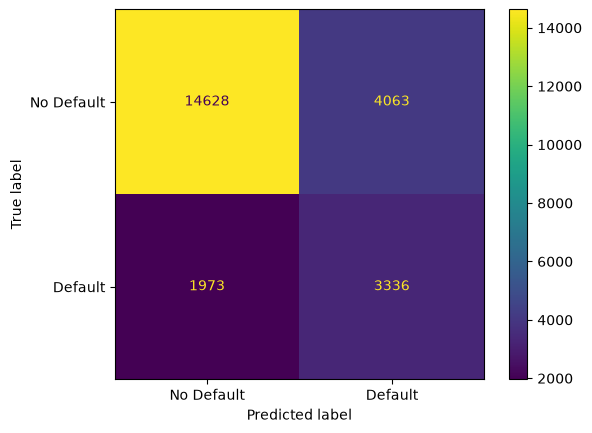

In [351]:
# Confusion Matrix - Tuned Logistic Regression

logistic_cv_pred = cross_val_predict(
    logistic_best,
    X_train_final,
    y_train,
    cv=10,
    n_jobs=-1
)

cm_logistic = confusion_matrix(y_train, logistic_cv_pred)

print("Confusion Matrix - Tuned Logistic Regression")
print(cm_logistic)

ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=['No Default', 'Default']
).plot()

plt.show()

In [352]:
# Logistic Regression Feature Importance

feature_names = logistic_best.named_steps['preprocessor'].get_feature_names_out()
coefficients = logistic_best.named_steps['classifier'].coef_[0]

logistic_features = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

logistic_features['Feature'] = (
    logistic_features['Feature']
    .str.replace('num__', '', regex=False)
    .str.replace('cat__', '', regex=False)
)

logistic_features['Absolute_Coefficient'] = (
    logistic_features['Coefficient'].abs()
)

top_logistic_features = (
    logistic_features
    .sort_values('Absolute_Coefficient', ascending=False)
    .head(10)
)

display(
    top_logistic_features[
        ['Feature', 'Coefficient']
    ].round(4)
)

,Feature,Coefficient
20,DELAY_COUNT,0.7822
21,MAX_DELAY,0.2962
2,PAY_0,0.1749
35,EDUCATION_3,0.1668
7,PAY_6,-0.1355
30,EDUCATION_LABOR_PARTICIPATION,0.1335
0,LIMIT_BAL,-0.1327
4,PAY_3,-0.1209
3,PAY_2,-0.1158
6,PAY_5,-0.1127


## Model 2: Random Forest

In [337]:
# Base Random Forest
rf_base = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

rf_base.fit(X_train_final, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](34,)","['LIMIT_BAL','SEX','EDUCATION',...,'PAYMENT_INCOME_RATIO', 'AGE_LABOR_PARTICIPATION','EDUCATION_LABOR_PARTICIPATION']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,34
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'

In [298]:
# Base Random Forest Performance

rf_base_scores = cross_validate(
    rf_base,
    X_train_final,
    y_train,
    cv=10,
    scoring=[
        'accuracy',
        'precision',
        'recall',
        'f1',
        'roc_auc',
        'average_precision'
    ],
    n_jobs=-1
)

print("Base Random Forest")
print("------------------")
print("Accuracy:", round(rf_base_scores['test_accuracy'].mean(), 4))
print("Precision:", round(rf_base_scores['test_precision'].mean(), 4))
print("Recall:", round(rf_base_scores['test_recall'].mean(), 4))
print("F1:", round(rf_base_scores['test_f1'].mean(), 4))
print("ROC-AUC:", round(rf_base_scores['test_roc_auc'].mean(), 4))
print("PR-AUC:", round(rf_base_scores['test_average_precision'].mean(), 4))

Base Random Forest
------------------
Accuracy: 0.8172
Precision: 0.6528
Recall: 0.372
F1: 0.4738
ROC-AUC: 0.7701
PR-AUC: 0.5382


In [341]:
# Tune Random Forest

rf_params = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_leaf': [2, 4],
    'classifier__class_weight': [None, 'balanced']
}

rf_grid = GridSearchCV(
    rf_base,
    rf_params,
    scoring={
        'Recall': 'recall',
        'ROC-AUC': 'roc_auc'
    },
    refit='Recall',
    cv=5,
    n_jobs=-1
)

rf_grid.fit(X_train_final, y_train)

print("Best Parameters:", rf_grid.best_params_)
print("Best CV Recall:", round(rf_grid.best_score_, 4))

Best Parameters: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 4, 'classifier__n_estimators': 200}
Best CV Recall: 0.6197


In [342]:
# Tuned Random Forest Performance

rf_best = rf_grid.best_estimator_

rf_tuned_scores = cross_validate(
    rf_best,
    X_train_final,
    y_train,
    cv=10,
    scoring=[
        'accuracy',
        'precision',
        'recall',
        'f1',
        'roc_auc',
        'average_precision'
    ],
    n_jobs=-1
)

print("Tuned Random Forest")
print("-------------------")
print("Accuracy:", round(rf_tuned_scores['test_accuracy'].mean(), 4))
print("Precision:", round(rf_tuned_scores['test_precision'].mean(), 4))
print("Recall:", round(rf_tuned_scores['test_recall'].mean(), 4))
print("F1:", round(rf_tuned_scores['test_f1'].mean(), 4))
print("ROC-AUC:", round(rf_tuned_scores['test_roc_auc'].mean(), 4))
print("PR-AUC:", round(rf_tuned_scores['test_average_precision'].mean(), 4))

Tuned Random Forest
-------------------
Accuracy: 0.7686
Precision: 0.4822
Recall: 0.6205
F1: 0.5426
ROC-AUC: 0.7857
PR-AUC: 0.5621


In [343]:
# Compare Base vs Tuned Random Forest

rf_comparison = pd.DataFrame({
    'Version': [
        'Base Random Forest',
        'Tuned Random Forest'
    ],
    'Accuracy': [
        rf_base_scores['test_accuracy'].mean(),
        rf_tuned_scores['test_accuracy'].mean()
    ],
    'Precision': [
        rf_base_scores['test_precision'].mean(),
        rf_tuned_scores['test_precision'].mean()
    ],
    'Recall': [
        rf_base_scores['test_recall'].mean(),
        rf_tuned_scores['test_recall'].mean()
    ],
    'F1': [
        rf_base_scores['test_f1'].mean(),
        rf_tuned_scores['test_f1'].mean()
    ],
    'ROC-AUC': [
        rf_base_scores['test_roc_auc'].mean(),
        rf_tuned_scores['test_roc_auc'].mean()
    ],
    'PR-AUC': [
        rf_base_scores['test_average_precision'].mean(),
        rf_tuned_scores['test_average_precision'].mean()
    ]
})

display(rf_comparison.round(4))

,Version,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Base Random Forest,0.8172,0.6528,0.3720,0.4738,0.7701,0.5382
1,Tuned Random Forest,0.7686,0.4822,0.6205,0.5426,0.7857,0.5621


Confusion Matrix - Tuned Random Forest
[[15152  3539]
 [ 2015  3294]]


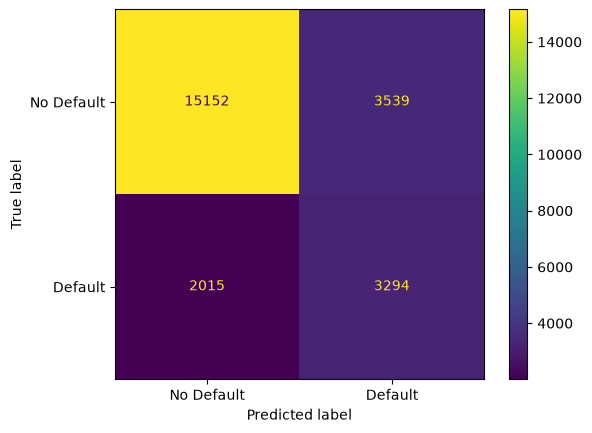

In [344]:
# Confusion Matrix - Tuned Random Forest

rf_cv_pred = cross_val_predict(
    rf_best,
    X_train_final,
    y_train,
    cv=10,
    n_jobs=-1
)

cm_rf = confusion_matrix(y_train, rf_cv_pred)

print("Confusion Matrix - Tuned Random Forest")
print(cm_rf)

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=['No Default', 'Default']
).plot()

plt.show()

In [345]:
# Random Forest Feature Importance

feature_names = rf_best.named_steps['preprocessor'].get_feature_names_out()
importances = rf_best.named_steps['classifier'].feature_importances_

rf_features = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

rf_features['Feature'] = (
    rf_features['Feature']
    .str.replace('num__', '', regex=False)
    .str.replace('cat__', '', regex=False)
)

top_rf_features = (
    rf_features
    .sort_values('Importance', ascending=False)
    .head(10)
)

display(top_rf_features.round(4))

,Feature,Importance
20,DELAY_COUNT,0.1389
2,PAY_0,0.1132
21,MAX_DELAY,0.1130
3,PAY_2,0.0647
4,PAY_3,0.0426
26,CREDIT_INCOME_RATIO,0.0354
24,UTILIZATION_RATIO,0.0324
23,AVG_PAY_AMT,0.0316
28,PAYMENT_INCOME_RATIO,0.0302
5,PAY_4,0.0274


## Model 3: XGBoost

In [353]:
# Base XGBoost
xgb_base = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss',
        tree_method='hist',
        n_jobs=-1
    ))
])

xgb_base.fit(X_train_final, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](34,)","['LIMIT_BAL','SEX','EDUCATION',...,'PAYMENT_INCOME_RATIO', 'AGE_LABOR_PARTICIPATION','EDUCATION_LABOR_PARTICIPATION']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,34
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'

In [354]:
# Base XGBoost Performance

xgb_base_scores = cross_validate(
    xgb_base,
    X_train_final,
    y_train,
    cv=10,
    scoring=[
        'accuracy',
        'precision',
        'recall',
        'f1',
        'roc_auc',
        'average_precision'
    ],
    n_jobs=-1
)

print("Base XGBoost")
print("------------")
print("Accuracy:", round(xgb_base_scores['test_accuracy'].mean(), 4))
print("Precision:", round(xgb_base_scores['test_precision'].mean(), 4))
print("Recall:", round(xgb_base_scores['test_recall'].mean(), 4))
print("F1:", round(xgb_base_scores['test_f1'].mean(), 4))
print("ROC-AUC:", round(xgb_base_scores['test_roc_auc'].mean(), 4))
print("PR-AUC:", round(xgb_base_scores['test_average_precision'].mean(), 4))

Base XGBoost
------------
Accuracy: 0.8221
Precision: 0.6825
Recall: 0.3673
F1: 0.4774
ROC-AUC: 0.786
PR-AUC: 0.5626


In [355]:
# Tune XGBoost

class_weight_ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb_params = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0],
    'classifier__scale_pos_weight': [1, class_weight_ratio]
}

xgb_grid = GridSearchCV(
    xgb_base,
    xgb_params,
    scoring={
        'Recall': 'recall',
        'ROC-AUC': 'roc_auc'
    },
    refit='Recall',
    cv=5,
    n_jobs=-1
)

xgb_grid.fit(X_train_final, y_train)

print("Class Weight Ratio:", round(class_weight_ratio, 2))
print("Best Parameters:", xgb_grid.best_params_)
print("Best CV Recall:", round(xgb_grid.best_score_, 4))

Class Weight Ratio: 3.52
Best Parameters: {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 200, 'classifier__scale_pos_weight': np.float64(3.520625353173856), 'classifier__subsample': 0.8}
Best CV Recall: 0.6506


In [356]:
# Tuned XGBoost Performance

xgb_best = xgb_grid.best_estimator_

xgb_tuned_scores = cross_validate(
    xgb_best,
    X_train_final,
    y_train,
    cv=10,
    scoring=[
        'accuracy',
        'precision',
        'recall',
        'f1',
        'roc_auc',
        'average_precision'
    ],
    n_jobs=-1
)

print("Tuned XGBoost")
print("-------------")
print("Recall:", round(xgb_tuned_scores['test_recall'].mean(), 4))
print("ROC-AUC:", round(xgb_tuned_scores['test_roc_auc'].mean(), 4))
print("PR-AUC:", round(xgb_tuned_scores['test_average_precision'].mean(), 4))
print("F1:", round(xgb_tuned_scores['test_f1'].mean(), 4))
print("Precision:", round(xgb_tuned_scores['test_precision'].mean(), 4))
print("Accuracy:", round(xgb_tuned_scores['test_accuracy'].mean(), 4))

Tuned XGBoost
-------------
Recall: 0.6519
ROC-AUC: 0.7875
PR-AUC: 0.5637
F1: 0.5408
Precision: 0.4621
Accuracy: 0.7551


In [357]:
# Compare Base vs Tuned XGBoost

xgb_comparison = pd.DataFrame({
    'Version': [
        'Base XGBoost',
        'Tuned XGBoost'
    ],
    'Accuracy': [
        xgb_base_scores['test_accuracy'].mean(),
        xgb_tuned_scores['test_accuracy'].mean()
    ],
    'Precision': [
        xgb_base_scores['test_precision'].mean(),
        xgb_tuned_scores['test_precision'].mean()
    ],
    'Recall': [
        xgb_base_scores['test_recall'].mean(),
        xgb_tuned_scores['test_recall'].mean()
    ],
    'F1': [
        xgb_base_scores['test_f1'].mean(),
        xgb_tuned_scores['test_f1'].mean()
    ],
    'ROC-AUC': [
        xgb_base_scores['test_roc_auc'].mean(),
        xgb_tuned_scores['test_roc_auc'].mean()
    ],
    'PR-AUC': [
        xgb_base_scores['test_average_precision'].mean(),
        xgb_tuned_scores['test_average_precision'].mean()
    ]
})

display(xgb_comparison.round(4))

,Version,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Base XGBoost,0.8221,0.6825,0.3673,0.4774,0.7860,0.5626
1,Tuned XGBoost,0.7551,0.4621,0.6519,0.5408,0.7875,0.5637


Confusion Matrix - Tuned XGBoost
[[14661  4030]
 [ 1848  3461]]


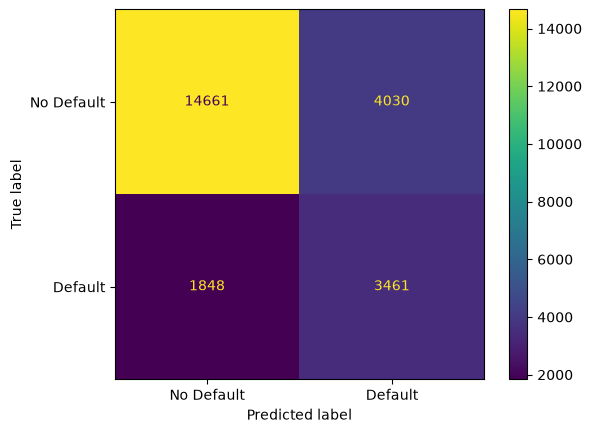

In [358]:
# Confusion Matrix - Tuned XGBoost

xgb_cv_pred = cross_val_predict(
    xgb_best,
    X_train_final,
    y_train,
    cv=10,
    n_jobs=-1
)

cm_xgb = confusion_matrix(y_train, xgb_cv_pred)

print("Confusion Matrix - Tuned XGBoost")
print(cm_xgb)

ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=['No Default', 'Default']
).plot()

plt.show()

In [359]:
# XGBoost Feature Importance

feature_names = xgb_best.named_steps['preprocessor'].get_feature_names_out()
importances = xgb_best.named_steps['classifier'].feature_importances_

xgb_features = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

xgb_features['Feature'] = (
    xgb_features['Feature']
    .str.replace('num__', '', regex=False)
    .str.replace('cat__', '', regex=False)
)

top_xgb_features = (
    xgb_features
    .sort_values('Importance', ascending=False)
    .head(10)
)

display(top_xgb_features.round(4))

,Feature,Importance
20,DELAY_COUNT,0.2921
21,MAX_DELAY,0.2236
2,PAY_0,0.0867
3,PAY_2,0.0238
27,BILL_INCOME_RATIO,0.0235
22,AVG_BILL_AMT,0.0224
24,UTILIZATION_RATIO,0.0223
26,CREDIT_INCOME_RATIO,0.0198
23,AVG_PAY_AMT,0.0195
15,PAY_AMT2,0.0162


## Model 4: CatBoost

In [360]:
# Base CatBoost

cat_features = ['SEX', 'EDUCATION', 'MARRIAGE']

catboost_base = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=0
)

catboost_base.fit(
    X_train_final,
    y_train,
    cat_features=cat_features
)

CatBoostClassifier(auto_class_weights='Balanced', depth=6, iterations=300, learning_rate=0.05, random_seed=42, verbose=0)

In [361]:
# Base CatBoost Performance

cv = StratifiedKFold(n_splits=10)

cat_base_results = []

for train_idx, val_idx in cv.split(X_train_final, y_train):

    X_tr = X_train_final.iloc[train_idx]
    X_val = X_train_final.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    model = CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        auto_class_weights='Balanced',
        random_seed=42,
        verbose=0
    )

    model.fit(X_tr, y_tr, cat_features=cat_features)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]

    cat_base_results.append([
        accuracy_score(y_val, y_pred),
        precision_score(y_val, y_pred),
        recall_score(y_val, y_pred),
        f1_score(y_val, y_pred),
        roc_auc_score(y_val, y_prob),
        average_precision_score(y_val, y_prob)
    ])

cat_base_results = pd.DataFrame(
    cat_base_results,
    columns=['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']
)

print("Base CatBoost")
print("-------------")
print(cat_base_results.mean().round(4))

Base CatBoost
-------------
Accuracy     0.7610
Precision    0.4707
Recall       0.6408
F1           0.5427
ROC-AUC      0.7871
PR-AUC       0.5624
dtype: float64


In [363]:
# Tuned CatBoost

catboost_best = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.02,
    l2_leaf_reg=3,
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=0
)
# Tune CatBoost

catboost_params = {
    'iterations': [200, 300],
    'depth': [4, 6],
    'learning_rate': [0.02, 0.05],
    'l2_leaf_reg': [3, 5]
}

catboost_grid = GridSearchCV(
    catboost_base,
    catboost_params,
    scoring={
        'Recall': 'recall',
        'ROC-AUC': 'roc_auc'
    },
    refit='Recall',
    cv=5,
    n_jobs=-1
)

catboost_grid.fit(
    X_train_final,
    y_train,
    cat_features=cat_features
)

print("Best Parameters:", catboost_grid.best_params_)
print("Best CV Recall:", round(catboost_grid.best_score_, 4))

Best Parameters: {'depth': 4, 'iterations': 300, 'l2_leaf_reg': 5, 'learning_rate': 0.05}
Best CV Recall: 0.6493


In [366]:
# Tuned CatBoost Performance

best_params = catboost_grid.best_params_

cat_tuned_results = []

for train_idx, val_idx in cv.split(X_train_final, y_train):

    X_tr = X_train_final.iloc[train_idx]
    X_val = X_train_final.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    model = CatBoostClassifier(
        iterations=best_params['iterations'],
        depth=best_params['depth'],
        learning_rate=best_params['learning_rate'],
        l2_leaf_reg=best_params['l2_leaf_reg'],
        auto_class_weights='Balanced',
        random_seed=42,
        verbose=0
    )

    model.fit(
        X_tr,
        y_tr,
        cat_features=cat_features
    )

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]

    cat_tuned_results.append([
        accuracy_score(y_val, y_pred),
        precision_score(y_val, y_pred),
        recall_score(y_val, y_pred),
        f1_score(y_val, y_pred),
        roc_auc_score(y_val, y_prob),
        average_precision_score(y_val, y_prob)
    ])

cat_tuned_results = pd.DataFrame(
    cat_tuned_results,
    columns=['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']
)

print("Tuned CatBoost")
print("--------------")
print("Recall:", round(cat_tuned_results['Recall'].mean(), 4))
print("ROC-AUC:", round(cat_tuned_results['ROC-AUC'].mean(), 4))
print("PR-AUC:", round(cat_tuned_results['PR-AUC'].mean(), 4))
print("F1:", round(cat_tuned_results['F1'].mean(), 4))
print("Precision:", round(cat_tuned_results['Precision'].mean(), 4))
print("Accuracy:", round(cat_tuned_results['Accuracy'].mean(), 4))

Tuned CatBoost
--------------
Recall: 0.6506
ROC-AUC: 0.7864
PR-AUC: 0.5588
F1: 0.5426
Precision: 0.4654
Accuracy: 0.7574


In [367]:
# Compare Base vs Tuned CatBoost

cat_comparison = pd.DataFrame({
    'Version': [
        'Base CatBoost',
        'Tuned CatBoost'
    ],

    'Accuracy': [
        cat_base_results['Accuracy'].mean(),
        cat_tuned_results['Accuracy'].mean()
    ],

    'Precision': [
        cat_base_results['Precision'].mean(),
        cat_tuned_results['Precision'].mean()
    ],

    'Recall': [
        cat_base_results['Recall'].mean(),
        cat_tuned_results['Recall'].mean()
    ],

    'F1': [
        cat_base_results['F1'].mean(),
        cat_tuned_results['F1'].mean()
    ],

    'ROC-AUC': [
        cat_base_results['ROC-AUC'].mean(),
        cat_tuned_results['ROC-AUC'].mean()
    ],

    'PR-AUC': [
        cat_base_results['PR-AUC'].mean(),
        cat_tuned_results['PR-AUC'].mean()
    ]
})

display(cat_comparison.round(4))

,Version,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Base CatBoost,0.7610,0.4707,0.6408,0.5427,0.7871,0.5624
1,Tuned CatBoost,0.7574,0.4654,0.6506,0.5426,0.7864,0.5588


Confusion Matrix - Tuned CatBoost
[[14723  3968]
 [ 1855  3454]]


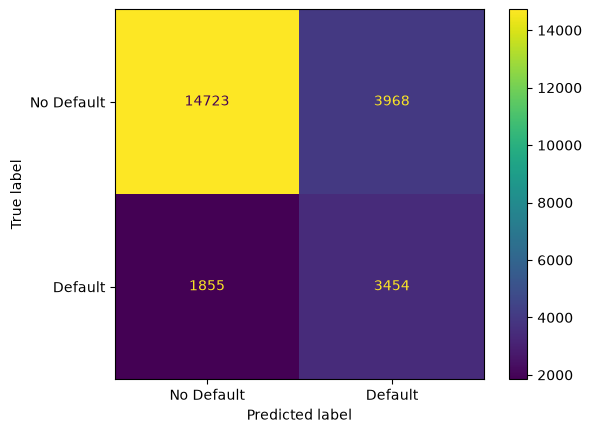

In [368]:
# Confusion Matrix - Tuned CatBoost

cat_cv_pred = np.zeros(len(y_train), dtype=int)

for train_idx, val_idx in cv.split(X_train_final, y_train):

    X_tr = X_train_final.iloc[train_idx]
    X_val = X_train_final.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]

    model = CatBoostClassifier(
        iterations=best_params['iterations'],
        depth=best_params['depth'],
        learning_rate=best_params['learning_rate'],
        l2_leaf_reg=best_params['l2_leaf_reg'],
        auto_class_weights='Balanced',
        random_seed=42,
        verbose=0
    )

    model.fit(
        X_tr,
        y_tr,
        cat_features=cat_features
    )

    cat_cv_pred[val_idx] = model.predict(X_val).ravel()

cm_cat = confusion_matrix(y_train, cat_cv_pred)

print("Confusion Matrix - Tuned CatBoost")
print(cm_cat)

ConfusionMatrixDisplay(
    confusion_matrix=cm_cat,
    display_labels=['No Default', 'Default']
).plot()

plt.show()

In [371]:
# CatBoost Feature Importance

catboost_best.fit(
    X_train_final,
    y_train,
    cat_features=cat_features,
    verbose=0
)

catboost_features = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Importance': catboost_best.get_feature_importance()
})

top_catboost_features = (
    catboost_features
    .sort_values('Importance', ascending=False)
    .head(10)
)

display(top_catboost_features.round(4))

,Feature,Importance
5,PAY_0,17.4560
24,MAX_DELAY,11.1678
23,DELAY_COUNT,8.5088
27,UTILIZATION_RATIO,6.7650
29,CREDIT_INCOME_RATIO,4.6170
11,BILL_AMT1,4.1132
0,LIMIT_BAL,3.7313
18,PAY_AMT2,2.9801
2,EDUCATION,2.9514
17,PAY_AMT1,2.9093


# Final Model Comparison

In [372]:
# Final Model Comparison

model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost',
        'CatBoost'
    ],

    'Recall': [
        logistic_tuned_scores['test_recall'].mean(),
        rf_tuned_scores['test_recall'].mean(),
        xgb_tuned_scores['test_recall'].mean(),
        cat_tuned_results['Recall'].mean()
    ],

    'ROC-AUC': [
        logistic_tuned_scores['test_roc_auc'].mean(),
        rf_tuned_scores['test_roc_auc'].mean(),
        xgb_tuned_scores['test_roc_auc'].mean(),
        cat_tuned_results['ROC-AUC'].mean()
    ],

    'PR-AUC': [
        logistic_tuned_scores['test_average_precision'].mean(),
        rf_tuned_scores['test_average_precision'].mean(),
        xgb_tuned_scores['test_average_precision'].mean(),
        cat_tuned_results['PR-AUC'].mean()
    ],

    'F1': [
        logistic_tuned_scores['test_f1'].mean(),
        rf_tuned_scores['test_f1'].mean(),
        xgb_tuned_scores['test_f1'].mean(),
        cat_tuned_results['F1'].mean()
    ],

    'Precision': [
        logistic_tuned_scores['test_precision'].mean(),
        rf_tuned_scores['test_precision'].mean(),
        xgb_tuned_scores['test_precision'].mean(),
        cat_tuned_results['Precision'].mean()
    ],

    'Accuracy': [
        logistic_tuned_scores['test_accuracy'].mean(),
        rf_tuned_scores['test_accuracy'].mean(),
        xgb_tuned_scores['test_accuracy'].mean(),
        cat_tuned_results['Accuracy'].mean()
    ]
})

display(
    model_comparison
    .sort_values('Recall', ascending=False)
    .round(4)
)

,Model,Recall,ROC-AUC,PR-AUC,F1,Precision,Accuracy
2,XGBoost,0.6519,0.7875,0.5637,0.5408,0.4621,0.7551
3,CatBoost,0.6506,0.7864,0.5588,0.5426,0.4654,0.7574
0,Logistic Regression,0.6284,0.7606,0.5119,0.5251,0.4511,0.7485
1,Random Forest,0.6205,0.7857,0.5621,0.5426,0.4822,0.7686


In [373]:
# Final Test Set Evaluation

models = {
    'Logistic Regression': logistic_best,
    'Random Forest': rf_best,
    'XGBoost': xgb_best,
    'CatBoost': catboost_best
}

test_results = []

for name, model in models.items():

    y_pred = model.predict(X_test_final)
    y_prob = model.predict_proba(X_test_final)[:, 1]

    test_results.append([
        name,
        recall_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob),
        average_precision_score(y_test, y_prob),
        f1_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        accuracy_score(y_test, y_pred)
    ])

test_results = pd.DataFrame(
    test_results,
    columns=[
        'Model',
        'Recall',
        'ROC-AUC',
        'PR-AUC',
        'F1',
        'Precision',
        'Accuracy'
    ]
)

display(test_results.round(4))

,Model,Recall,ROC-AUC,PR-AUC,F1,Precision,Accuracy
0,Logistic Regression,0.6036,0.7453,0.4988,0.5112,0.4433,0.7447
1,Random Forest,0.6172,0.7768,0.5550,0.5393,0.4789,0.7668
2,XGBoost,0.6338,0.7802,0.5621,0.5296,0.4548,0.7510
3,CatBoost,0.6277,0.7790,0.5609,0.5323,0.4620,0.7560


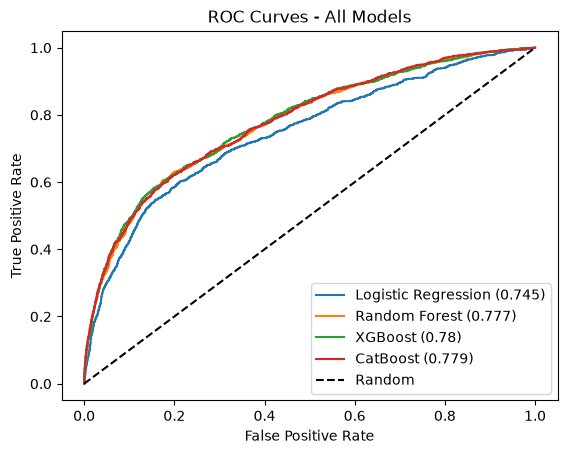

In [376]:
# ROC Curves - All Models

from sklearn.metrics import roc_curve

for name, model in models.items():

    y_score = model.predict_proba(X_test_final)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_score)

    auc = roc_auc_score(y_test, y_score)

    plt.plot(
        fpr,
        tpr,
        label=name + ' (' + str(round(auc, 3)) + ')'
    )

plt.plot([0, 1], [0, 1], 'k--', label='Random')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend()

plt.show()

### ROC Curve Interpretation

XGBoost achieved the highest test ROC-AUC of 0.780, followed closely by CatBoost (0.779) and Random Forest (0.777). Logistic Regression achieved a lower ROC-AUC of 0.745.

Overall, the tree-based models showed better ability to distinguish between customers who default and those who do not.

Final XGBoost Confusion Matrix
[[3665 1008]
 [ 486  841]]


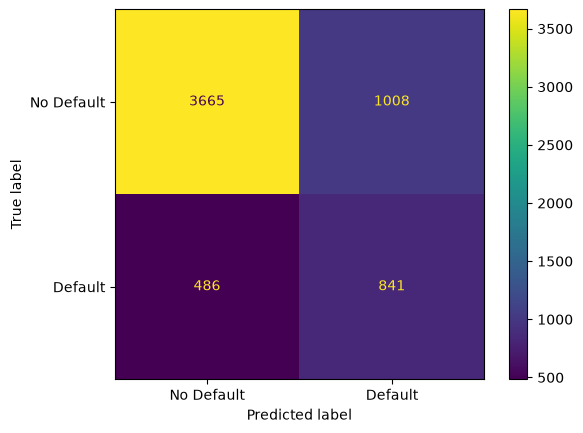

In [374]:
# Final XGBoost Confusion Matrix

xgb_test_pred = xgb_best.predict(X_test_final)

cm_xgb_test = confusion_matrix(y_test, xgb_test_pred)

print("Final XGBoost Confusion Matrix")
print(cm_xgb_test)

ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb_test,
    display_labels=['No Default', 'Default']
).plot()

plt.show()

## Conclusion

Four classification models were evaluated: Logistic Regression, Random Forest, XGBoost, and CatBoost.

XGBoost was selected as the final model because it achieved the highest 10-fold cross-validation Recall of 0.6519, together with the strongest ROC-AUC of 0.7875 and PR-AUC of 0.5637.

Recall was prioritized because failing to identify a customer who may default can create greater financial risk than incorrectly flagging a non-defaulter.

The final model was also evaluated on the unseen test set to check its ability to generalize beyond the training data.

The results show that repayment behaviour, especially previous payment delays, is highly important for predicting credit-card default.

### Business Implication

The model could support credit-risk assessment by helping financial institutions identify customers with a higher probability of default and allowing earlier risk-management actions.

### Limitations

- The dataset represents credit-card customers in Taiwan from 2005.
- The target classes are moderately imbalanced.
- External socioeconomic features are group-level estimates rather than actual customer income or employment information.
- Model predictions should support, rather than replace, human credit-risk assessment.

### Future Improvements

Future work could use more recent customer data, additional financial variables, further feature engineering, and threshold optimization based on the financial cost of false negatives and false positives.

## References & Appendix (edit it)

**Dataset:** https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset/data

**External data:** https://eng.stat.gov.tw/News_Content.aspx
-Taiwan 2005 age-group income and labor-force-participation estimates, used 
to construct income and labor-participation proxy features for the external enrichment 
experiment.

**Libraries used:** pandas, NumPy, Matplotlib, Seaborn, SciPy (chi2_contingency), 
scikit-learn (preprocessing, pipelines, model selection, ensemble and linear models, metrics), 
XGBoost, CatBoost.